# New Set Example

In [1]:
import os, pathlib
os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")
import ML_amber, inspect, sys, importlib

from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
print("Imported ML.py from:", ML_amber.__file__)

Imported ML.py from: /Users/gregcc/Documents/GitHub/SURP25/Microlensing/ML_amber.py


In [2]:
from ML_amber import ThreeLens1S
from ML_amber import TwoLens1S

In [3]:
#parameters from Liebig, et al; (2010)
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2 #for binary system
u0_list =[0.0155] #paper

u0_list_n = [-0.0155]

t0 = 0
tE = 20
rho = 1.8e-3
rs = rho

secnum = 45
basenum = 2
num_points = 200

In [4]:
#triple system
triple_model = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3, 0, psi, rs, secnum, basenum, num_points)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]
mag, *_ = triple_model.VBM.TripleLightCurve(param, triple_model.highres_t)

triple_model_tau = triple_model.highres_tau
triple_model_mag = mag



In [5]:
#triple system
trinary_model = ThreeLens1S(t0, tE, rho, u0_list_n, q2, q3, s2, s3, 0, psi, rs, secnum, basenum, num_points)

param_n = [
    np.log(trinary_model.s2), np.log(trinary_model.q2), trinary_model.u0_list[0], trinary_model.alpha_deg,
    np.log(trinary_model.rho), np.log(trinary_model.tE), trinary_model.t0,
    np.log(trinary_model.s3), np.log(trinary_model.q3), trinary_model.psi_rad
]
mag_n, *_ = trinary_model.VBM.TripleLightCurve(param_n, trinary_model.highres_t)

trinaty_model_tau = trinary_model.highres_tau
trinary_model_mag = mag_n

In [6]:
#binary system
double_model = TwoLens1S(t0, tE, rho, u0_list, q4, s2, 0, t_lc= triple_model.highres_t )
A_bin = double_model.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

binary_model = TwoLens1S(t0, tE, rho, u0_list, q2, s2, 0, t_lc= triple_model.highres_t )
B_bin = binary_model.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

(0.0, 10.0)

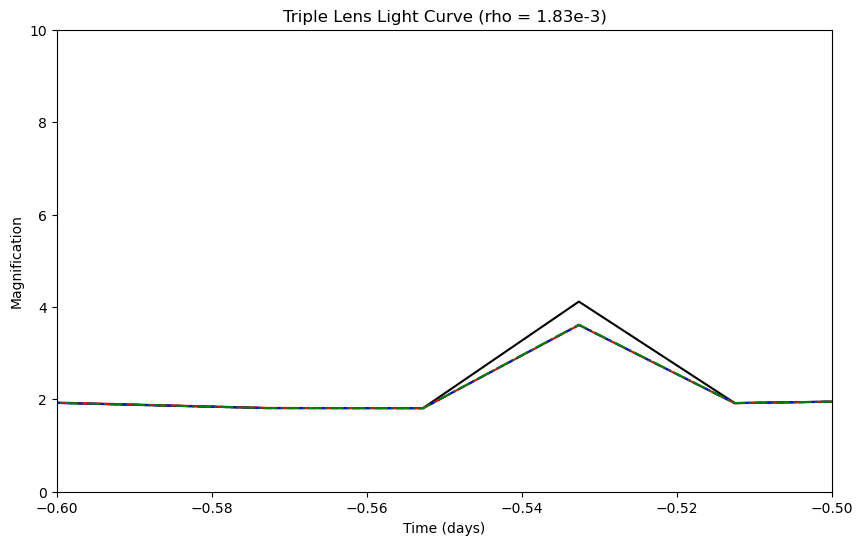

In [7]:
# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model.highres_tau, triple_model_mag, 'k-')
plt.plot(trinary_model.highres_tau, trinary_model_mag, 'r-')
plt.plot(triple_model_tau, A_bin, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau, B_bin, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel('Time (days)')
plt.ylabel('Magnification')
plt.title('Triple Lens Light Curve (rho = 1.83e-3)')
plt.xlim((-0.6, -0.5))
plt.ylim((0, 10))

u0=0.0155 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.0155 -0.0155 -0.0155 -0.0155 -0.0155]
u0=0.0155 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.0155 -0.0155 -0.0155 -0.0155 -0.0155]


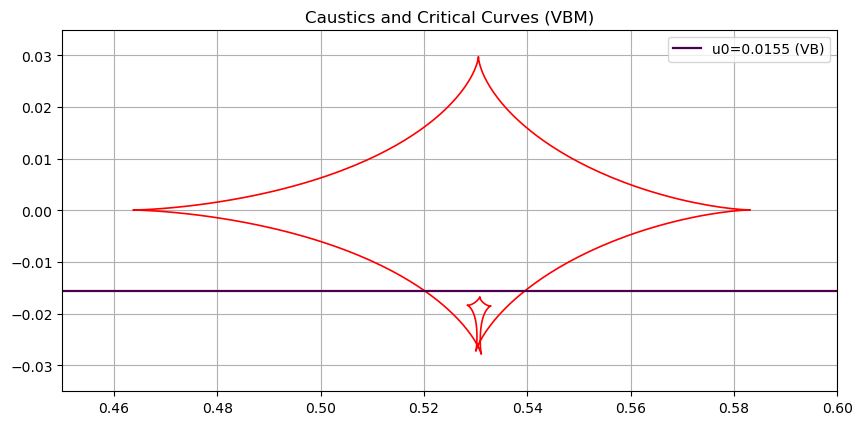

In [8]:
triple_model.plot_caustics_and_critical(show = False)
ax = plt.gca()
ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.035, 0.035)
plt.show()

u0=-0.0155 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.0155 0.0155 0.0155 0.0155 0.0155]
u0=-0.0155 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[0.0155 0.0155 0.0155 0.0155 0.0155]


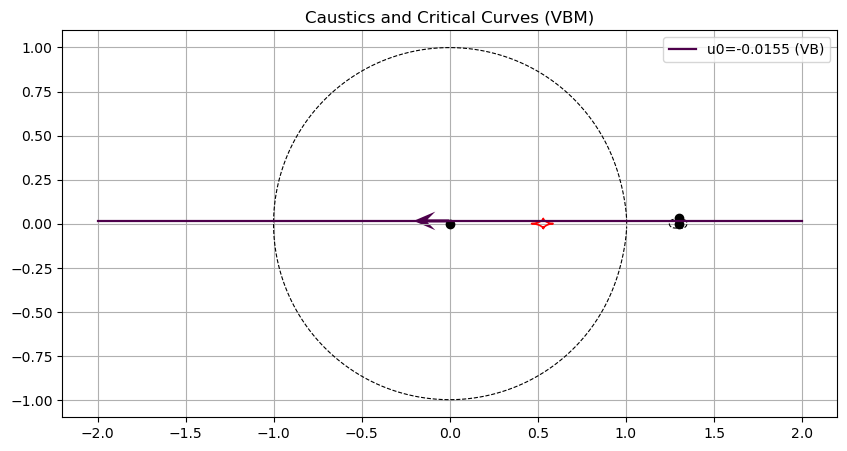

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Caustics and Critical Curves (VBM)'}>)

In [9]:
trinary_model.plot_caustics_and_critical()

In [16]:
two_system    = double_model.systems[0]
binary_system = binary_model.systems[0]
three_system  = triple_model.systems[0]
trinary_system = trinary_model.systems[0]

# 2L1S (high-res)
delta_x_two = two_system['cent_x_lc'] - two_system['y1s_lc']
delta_y_two = two_system['cent_y_lc'] - two_system['y2s_lc']

delta_x_two_B = binary_system['cent_x_lc'] - binary_system['y1s_lc']
delta_y_two_B = binary_system['cent_y_lc'] - binary_system['y2s_lc']

# 3L1S (standard res in your build)
delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = delta_x_three
delta_y_three = -delta_y_three

#negative u0
delta_x_three_n = trinary_system['cent_x'] - trinary_system['y1s']
delta_y_three_n = trinary_system['cent_y'] - trinary_system['y2s']

delta_x_three_n = delta_x_three_n
delta_y_three_n = delta_y_three_n

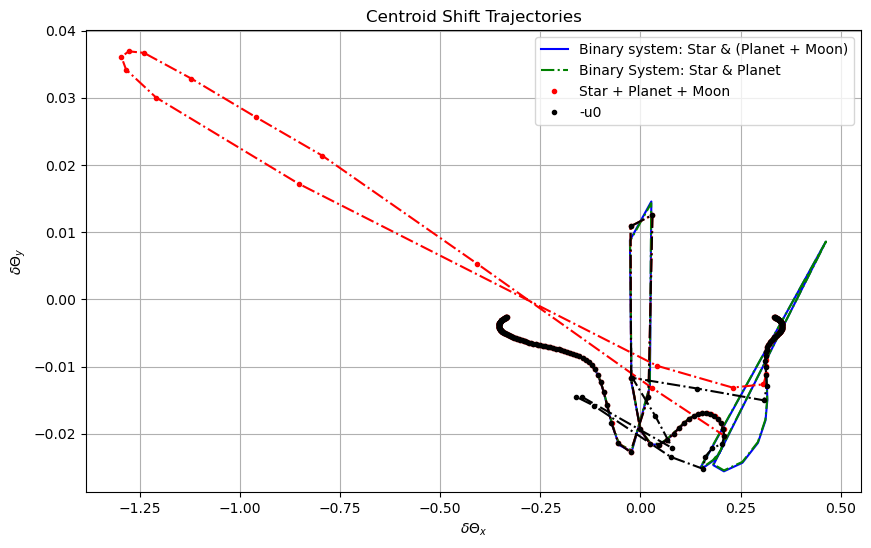

In [17]:
#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two, delta_y_two, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B, delta_y_two_B, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three, delta_y_three, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three, delta_y_three, 'r-.')

plt.plot(delta_x_three_n, delta_y_three_n, 'k.', label='-u0')
plt.plot(delta_x_three_n, delta_y_three_n, 'k-.')

plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

In [18]:
delta_triple = (delta_x_three**2 + delta_y_three**2)**0.5
delta_double_A = (delta_x_two**2 + delta_y_two**2)**0.5
delta_double_B = (delta_x_two_B**2 + delta_y_two_B**2)**0.5

delta_trinary = (delta_x_three_n**2 + delta_y_three_n**2)**0.5

triple_model_tau_changed = -triple_model_tau

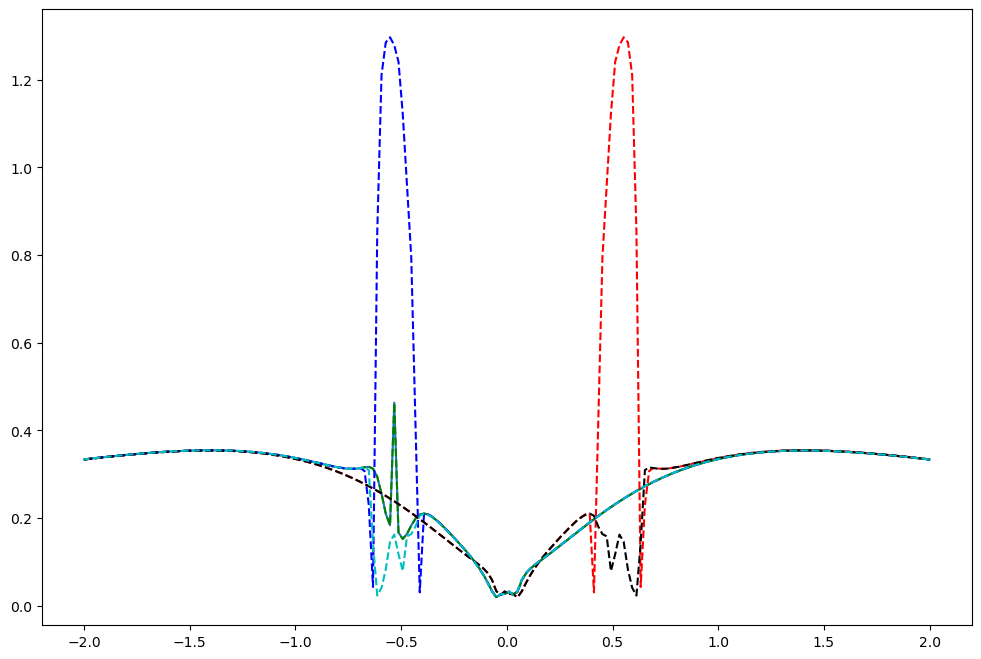

In [19]:
plt.figure(figsize=(12, 8))

plt.plot(triple_model_tau, delta_double_B)
plt.plot(triple_model_tau, delta_double_A, 'g--')
plt.plot(triple_model_tau , delta_triple,  'r--')
plt.plot(triple_model_tau_changed, delta_triple, 'b--')

plt.plot(triple_model_tau , delta_trinary,  'k--')
plt.plot(triple_model_tau_changed, delta_trinary, 'c--')


#plt.xlim((-0.6, -0.5))


In [14]:
len(delta_x_two_B)

200